In [19]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\praji\Downloads\archive (5)\amazon_delivery.csv")

print("Dataset Info:")
print(df.info())

print("\nShape of Dataset:", df.shape)

print("\nColumns:")
print(df.columns)


# Remove duplicates
df.drop_duplicates(inplace=True)

# Clean column names
df.columns = df.columns.str.strip()

# Missing values
print("\n❗ Missing Values Before Cleaning:")
print(df.isnull().sum())

df.dropna(inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

try:
    df['Order_Time'] = pd.to_datetime(df['Order_Time'])
    df['Pickup_Time'] = pd.to_datetime(df['Pickup_Time'])
    df['Delivery_Time'] = pd.to_datetime(df['Delivery_Time'])
    print("\nTime columns converted successfully")
except Exception as e:
    print("\nTime conversion issue:", e)

print("\nUnique Values:")
try:
    print("Weather:", df['Weather'].unique())
    print("Traffic:", df['Traffic'].unique())
    print("Vehicle:", df['Vehicle'].unique())
    print("Area:", df['Area'].unique())
except:
    print("Some columns not found, check column names")

print("\nSummary Statistics:")
print(df.describe())

print("\nFinal Data Preview:")
print(df.head(10))


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  object 
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  object 
 8   Order_Time       43739 non-null  object 
 9   Pickup_Time      43739 non-null  object 
 10  Weather          43648 non-null  object 
 11  Traffic          43739 non-null  object 
 12  Vehicle          43739 non-null  object 
 13  Area             43739 non-null  object 
 14  Delivery_Time    43739 non-null  int64  
 15  Category         43739 non-null  object 
dtypes: float64(5), int64(2), object(9)
memory us

C:\Users\praji\AppData\Local\Temp\ipykernel_30940\1362441105.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order_Time'] = pd.to_datetime(df['Order_Time'])
C:\Users\praji\AppData\Local\Temp\ipykernel_30940\1362441105.py:32: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Pickup_Time'] = pd.to_datetime(df['Pickup_Time'])


In [20]:

# Convert to datetime
df['Order_Time'] = pd.to_datetime(df['Order_Time'], errors='coerce')
df['Pickup_Time'] = pd.to_datetime(df['Pickup_Time'], errors='coerce')
df['Delivery_Time'] = pd.to_datetime(df['Delivery_Time'], errors='coerce')

# Force same base date
df['Order_Time'] = df['Order_Time'].apply(lambda x: x.replace(year=2024, month=1, day=1))
df['Pickup_Time'] = df['Pickup_Time'].apply(lambda x: x.replace(year=2024, month=1, day=1))
df['Delivery_Time'] = df['Delivery_Time'].apply(lambda x: x.replace(year=2024, month=1, day=1))

#  If pickup < order → next day
df.loc[df['Pickup_Time'] < df['Order_Time'], 'Pickup_Time'] += pd.Timedelta(days=1)

#  If delivery < pickup → next day
df.loc[df['Delivery_Time'] < df['Pickup_Time'], 'Delivery_Time'] += pd.Timedelta(days=1)

# Recalculate time features
df['Prep_Time_min'] = (df['Pickup_Time'] - df['Order_Time']).dt.total_seconds() / 60
df['Delivery_Time_min'] = (df['Delivery_Time'] - df['Pickup_Time']).dt.total_seconds() / 60
df['Total_Time_min'] = (df['Delivery_Time'] - df['Order_Time']).dt.total_seconds() / 60

print("Midnight issue fixed!\n")

print(df[['Prep_Time_min', 'Delivery_Time_min', 'Total_Time_min']].head())

Midnight issue fixed!

   Prep_Time_min  Delivery_Time_min  Total_Time_min
0           15.0              735.0           750.0
1            5.0              250.0           255.0
2           15.0              915.0           930.0
3           10.0              350.0           360.0
4           15.0              615.0           630.0


In [21]:
import numpy as np


# 1. DISTANCE CALCULATION (Haversine)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius (km)

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

df['Distance_km'] = haversine(
    df['Store_Latitude'], df['Store_Longitude'],
    df['Drop_Latitude'], df['Drop_Longitude']
)


# 2. TIME FEATURES

# Preparation Time (minutes)
df['Prep_Time_min'] = (df['Pickup_Time'] - df['Order_Time']).dt.total_seconds() / 60

# Delivery Time (minutes)
df['Delivery_Time_min'] = (df['Delivery_Time'] - df['Pickup_Time']).dt.total_seconds() / 60

# Total Time (minutes)
df['Total_Time_min'] = (df['Delivery_Time'] - df['Order_Time']).dt.total_seconds() / 60

print("Time features created")

# 3. ENCODE CATEGORICAL VARIABLES

# Traffic Encoding
traffic_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['Traffic_Encoded'] = df['Traffic'].map(traffic_map)

# Weather Encoding
weather_map = {'Clear': 0, 'Cloudy': 1, 'Rainy': 2, 'Foggy': 3, 'Stormy': 4}
df['Weather_Encoded'] = df['Weather'].map(weather_map)

# Vehicle Encoding
vehicle_map = {'Bike': 0, 'Scooter': 1, 'Car': 2}
df['Vehicle_Encoded'] = df['Vehicle'].map(vehicle_map)

# Area Encoding
area_map = {'Urban': 0, 'Semi-Urban': 1, 'Rural': 2}
df['Area_Encoded'] = df['Area'].map(area_map)

print("Categorical features encoded")

# 4. FINAL CHECK
print("\nNew Features Preview:")
print(df[['Distance_km', 'Prep_Time_min', 'Delivery_Time_min', 'Total_Time_min']].head())


Time features created
Categorical features encoded

New Features Preview:
   Distance_km  Prep_Time_min  Delivery_Time_min  Total_Time_min
0     3.025149           15.0              735.0           750.0
1    20.183530            5.0              250.0           255.0
2     1.552758           15.0              915.0           930.0
3     7.790401           10.0              350.0           360.0
4     6.210138           15.0              615.0           630.0


In [22]:

import numpy as np

# Fill missing encoded values
df['Vehicle_Encoded'] = df['Vehicle_Encoded'].fillna(0)
df['Traffic_Encoded'] = df['Traffic_Encoded'].fillna(1)

# Base speed (km per minute)
speed_map = {
    0: 0.5,   # Bike
    1: 0.6,   # Scooter
    2: 0.8    # Car
}

# Traffic impact
traffic_factor = {
    0: 1.0,   # Low
    1: 0.7,   # Medium
    2: 0.5    # High
}

# Apply mapping safely
speed = df['Vehicle_Encoded'].map(speed_map)
traffic = df['Traffic_Encoded'].map(traffic_factor)

# Fill any remaining NaNs
speed = speed.fillna(0.5)
traffic = traffic.fillna(0.7)

# Calculate delivery time
df['Simulated_Delivery_Time'] = (df['Distance_km'] / speed) / traffic

# Add randomness
df['Simulated_Delivery_Time'] += np.random.normal(5, 2, len(df))

# Ensure valid values
df['Simulated_Delivery_Time'] = df['Simulated_Delivery_Time'].clip(lower=5)

print("Simulation fixed!\n")

print(df[['Distance_km', 'Vehicle_Encoded', 'Traffic_Encoded', 'Simulated_Delivery_Time']].head())

Simulation fixed!

   Distance_km  Vehicle_Encoded  Traffic_Encoded  Simulated_Delivery_Time
0     3.025149              0.0              1.0                 8.734847
1    20.183530              0.0              1.0                61.904693
2     1.552758              0.0              1.0                12.442931
3     7.790401              0.0              1.0                23.940335
4     6.210138              0.0              1.0                21.029263


In [23]:

# Fill missing categorical encodings
df['Weather_Encoded'] = df['Weather_Encoded'].fillna(0)
df['Area_Encoded'] = df['Area_Encoded'].fillna(0)

# Also ensure Traffic & Vehicle are clean
df['Traffic_Encoded'] = df['Traffic_Encoded'].fillna(1)
df['Vehicle_Encoded'] = df['Vehicle_Encoded'].fillna(0)

# Final check
print("Missing values after fix:\n")
print(df[['Traffic_Encoded', 'Weather_Encoded', 'Vehicle_Encoded', 'Area_Encoded']].isnull().sum())


# Keep only reasonable delivery times
df = df[
    (df['Simulated_Delivery_Time'] >= 5) & 
    (df['Simulated_Delivery_Time'] <= 120)
]


print(df['Simulated_Delivery_Time'].describe())

Missing values after fix:

Traffic_Encoded    0
Weather_Encoded    0
Vehicle_Encoded    0
Area_Encoded       0
dtype: int64
count    43443.000000
mean        32.817475
std         16.141874
min          5.000000
25%         19.367179
50%         31.588296
75%         43.760214
max         70.248023
Name: Simulated_Delivery_Time, dtype: float64


In [24]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. SELECT FEATURES & TARGET

features = [
    'Distance_km',
    'Traffic_Encoded',
    'Weather_Encoded',
    'Vehicle_Encoded',
    'Area_Encoded'
]

X = df[features]
y = df['Simulated_Delivery_Time']

# 2. TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 3. TRAIN MODEL

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


# 4. PREDICTION

y_pred = model.predict(X_test)

# 5. EVALUATION

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("MAE (Error):", mae)
print("R2 Score:", r2)

# 6. SAMPLE PREDICTIONS

results = X_test.copy()
results['Actual'] = y_test
results['Predicted'] = y_pred

print("\nSample Predictions:")
print(results.head())



Model Performance:
MAE (Error): 1.7740816182405519
R2 Score: 0.9808378930265395

Sample Predictions:
       Distance_km  Traffic_Encoded  Weather_Encoded  Vehicle_Encoded  \
17531     4.610134              1.0              1.0              0.0   
39018    19.363385              1.0              1.0              0.0   
30091    20.067971              1.0              4.0              0.0   
31939     9.314921              1.0              0.0              0.0   
36388     7.772040              1.0              4.0              0.0   

       Area_Encoded     Actual  Predicted  
17531           0.0  19.098221  18.089817  
39018           0.0  58.888117  60.055409  
30091           0.0  60.904841  61.652408  
31939           0.0  34.769989  30.496496  
36388           0.0  28.113628  27.809173  


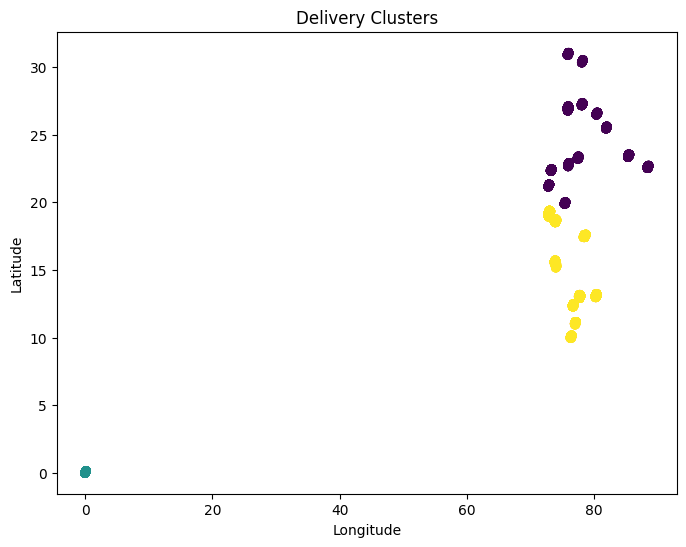


📊 Cluster Distribution:
Cluster
2    22259
0    17699
1     3485
Name: count, dtype: int64


In [25]:

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. SELECT LOCATION FEATURES

X_cluster = df[['Drop_Latitude', 'Drop_Longitude']]

# 2. APPLY K-MEANS

k = 3  

kmeans = KMeans(n_clusters=k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_cluster)


# 3. VISUALIZE CLUSTERS

plt.figure(figsize=(8,6))
plt.scatter(df['Drop_Longitude'], df['Drop_Latitude'], c=df['Cluster'])
plt.title("Delivery Clusters")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# 4. CHECK RESULTS

print("\n📊 Cluster Distribution:")
print(df['Cluster'].value_counts())


In [26]:
import sys
!{sys.executable} -m pip install ortools


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import ortools
print("OR-Tools installed successfully")

OR-Tools installed successfully


In [ ]:

import numpy as np

def fast_route(points):
    n = len(points)

    if n <= 1:
        return list(range(n))

    visited = np.zeros(n, dtype=bool)
    route = [0]
    visited[0] = True

    for _ in range(n - 1):

        last = route[-1]

        # compute distances ONLY from last node
        distances = np.linalg.norm(points - points[last], axis=1)

        # ignore visited nodes
        distances[visited] = np.inf

        next_idx = np.argmin(distances)

        route.append(int(next_idx))
        visited[next_idx] = True

    return route


# Apply per cluster
routes = {}

for cluster_id in df['Cluster'].unique():

    cluster_data = df[df['Cluster'] == cluster_id].dropna(
        subset=['Drop_Latitude', 'Drop_Longitude']
    ).reset_index(drop=True)

    points = cluster_data[['Drop_Latitude', 'Drop_Longitude']].values

    if len(points) < 2:
        routes[cluster_id] = [0] if len(points) == 1 else []
        continue

    route = fast_route(points)
    routes[cluster_id] = route


print("FIXED FAST Routes optimized for all clusters!\n")

for k, v in routes.items():
    print(f"Cluster {k} Route (first 10): {v[:10]}")


FIXED FAST Routes optimized for all clusters!

Cluster 0 Route (first 10): [0, 321, 567, 602, 687, 4921, 7788, 11373, 12089, 13528]
Cluster 2 Route (first 10): [0, 853, 1044, 1062, 3096, 3637, 3938, 7850, 12751, 16670]
Cluster 1 Route (first 10): [0, 9, 31, 50, 59, 60, 80, 90, 114, 115]

STEP 5 COMPLETED SUCCESSFULLY!


In [29]:

agents = {
    "Agent_1": {"load": 0, "deliveries": []},
    "Agent_2": {"load": 0, "deliveries": []},
    "Agent_3": {"load": 0, "deliveries": []}
}

# sort full dataset by cluster (for locality)
df_sorted = df.sort_values('Cluster')

# assign each delivery to least loaded agent
for idx, row in df_sorted.iterrows():

    best_agent = min(agents, key=lambda a: agents[a]["load"])

    agents[best_agent]["deliveries"].append(idx)
    agents[best_agent]["load"] += 1


# results
for agent, info in agents.items():
    print(f"\n👤 {agent}")
    print(f"Total Deliveries: {info['load']}")
    print(f"Sample Deliveries: {info['deliveries'][:10]}")



👤 Agent_1
Total Deliveries: 14481
Sample Deliveries: [2677, 43680, 49, 42, 43697, 43691, 43733, 19223, 13, 6]

👤 Agent_2
Total Deliveries: 14481
Sample Deliveries: [43682, 23661, 48, 37, 23659, 19224, 43731, 19222, 12, 21340]

👤 Agent_3
Total Deliveries: 14481
Sample Deliveries: [43681, 43674, 44, 43699, 43692, 43734, 43727, 19219, 9, 21336]


In [30]:
import sys
!{sys.executable} -m pip install folium


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import folium
from folium.plugins import MarkerCluster
center_lat = df['Drop_Latitude'].mean()
center_lon = df['Drop_Longitude'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 'cadetblue']

# Plot clusters + routes
for cluster_id in df['Cluster'].unique():

    cluster_data = df[df['Cluster'] == cluster_id].dropna(
        subset=['Drop_Latitude', 'Drop_Longitude']
    ).reset_index(drop=True)

    points = cluster_data[['Drop_Latitude', 'Drop_Longitude']].values

    color = colors[int(cluster_id) % len(colors)]

    marker_cluster = MarkerCluster().add_to(m)

    for i, row in cluster_data.iterrows():
        folium.Marker(
            location=[row['Drop_Latitude'], row['Drop_Longitude']],
            popup=f"Cluster {cluster_id} | Order {i}",
            icon=folium.Icon(color=color)
        ).add_to(marker_cluster)

    if len(points) > 1:
        route = routes.get(cluster_id, list(range(len(points))))
        route_points = [points[i] for i in route if i < len(points)]

        folium.PolyLine(
            route_points,
            color=color,
            weight=3,
            opacity=0.8
        ).add_to(m)

m.save("delivery_routes_map.html")